# Safe-RL baselines for safe policy optimisation

The `safe_rl_baselines` package provides three PyTorch **constrained-MDP** algorithms that
maximise reward while keeping a cumulative **cost** below a limit:

$$\max_\pi\; \mathbb{E}\!\Big[\textstyle\sum_t \gamma^t r_t\Big]\quad\text{s.t.}\quad
\mathbb{E}\!\Big[\textstyle\sum_t \gamma_c^t c_t\Big] \le \text{cost\_limit}.$$

| Algorithm | How the constraint is enforced |
|---|---|
| `PPOLagrangian` | A Lagrange multiplier $\lambda$ updated by a **naive integral** rule |
| `PPOPIDLagrangian` | $\lambda$ is the output of a **PID controller** on the cost violation (Stooke et al. 2020) |
| `CPO` | A **trust-region** step (TRPO-family) with an analytic constrained update (Achiam et al. 2017) |

All three share the same API (`learn`, `predict`) and read the per-step cost from a user
`cost_fn(obs, action, reward, next_obs, terminated, truncated, info)` (or `info["cost"]`).

**Demo:** `CartPole-v1` where pushing **left** (`action == 0`) costs 1 per step. Balancing the
pole normally uses both actions about equally, so the unconstrained cost is high. A safe agent
must trade off reward (staying up) against the cost budget.

In [1]:
# Make the repo's packages importable regardless of how the kernel was started.
import sys
from pathlib import Path

def _repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for path in (start, *start.parents):
        if (path / 'core').is_dir() and (path / '.git').exists():
            return path
    raise FileNotFoundError("Could not locate the repo root (a dir with 'core/' and '.git').")

REPO_ROOT = _repo_root()
for p in (str(REPO_ROOT), str(REPO_ROOT / 'core')):
    if p not in sys.path:
        sys.path.insert(0, p)

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from safe_rl_baselines import PPOLagrangian, PPOPIDLagrangian, CPO

# Per-step cost: 1 whenever the agent takes the costly action (push left).
def left_is_costly(obs, action, reward, next_obs, terminated, truncated, info):
    return 1.0 if int(action) == 0 else 0.0

COST_LIMIT = 5.0          # discounted budget for the costly action per episode
TOTAL_STEPS = 16000
CHUNK = 2000

def train_tracked(model, total=TOTAL_STEPS, chunk=CHUNK):
    # Train in chunks, recording mean episode cost and lambda over time.
    steps, cost, lam = [], [], []
    while model.num_timesteps < total:
        model.learn(total_timesteps=model.num_timesteps + chunk)
        steps.append(model.num_timesteps)
        cost.append(model.last_stats.get('mean_episode_cost', float('nan')))
        lam.append(float(getattr(model, 'lagrangian_multiplier', float('nan'))))
    return steps, cost, lam

def evaluate(model, episodes=20):
    # Deterministic costly-action frequency and mean episode cost.
    env = gym.make('CartPole-v1')
    left = total = ep_cost = 0
    for ep in range(episodes):
        obs, _ = env.reset(seed=2000 + ep)
        done = False
        while not done:
            action = int(np.asarray(model.predict(obs, deterministic=True)[0]))
            left += int(action == 0); total += 1; ep_cost += int(action == 0)
            obs, _, term, trunc, _ = env.step(action)
            done = term or trunc
    return left / total, ep_cost / episodes

COMMON = dict(cost_fn=left_is_costly, cost_limit=COST_LIMIT, n_steps=2000,
              seed=0, device='cpu', net_arch=(64, 64))

## 1. PPO-Lagrangian (naive dual)

The multiplier follows $\lambda \leftarrow \max(0,\ \lambda + \eta\,(J_C - \text{limit}))$.

In [3]:
ppolag = PPOLagrangian(gym.make('CartPole-v1'), n_epochs=10, lambda_lr=0.05, **COMMON)
s_lag, c_lag, l_lag = train_tracked(ppolag)
print('PPO-Lagrangian   final lambda=%.3f  mean cost=%.2f' % (l_lag[-1], c_lag[-1]))

PPO-Lagrangian   final lambda=0.420  mean cost=6.06


## 2. PID-Lagrangian

The multiplier is a PID controller on the cost violation, which responds faster and overshoots
less than the integral-only rule.

In [4]:
pidlag = PPOPIDLagrangian(gym.make('CartPole-v1'), n_epochs=10,
                          pid_kp=0.25, pid_ki=0.05, pid_kd=0.1, **COMMON)
s_pid, c_pid, l_pid = train_tracked(pidlag)
print('PID-Lagrangian   final lambda=%.3f  mean cost=%.2f' % (l_pid[-1], c_pid[-1]))
print('  PID terms:', {k: round(v, 3) for k, v in pidlag.pid_terms.items()})

PID-Lagrangian   final lambda=0.000  mean cost=2.87
  PID terms: {'P': -0.532, 'I': 0.412, 'D': 0.005}


## 3. CPO (trust-region)

CPO has no Lagrange multiplier; each update solves a constrained trust-region problem directly
(falling back to a cost-reducing *recovery* step when the current policy is infeasible).

In [5]:
cpo = CPO(gym.make('CartPole-v1'), target_kl=0.02, cg_iters=10, n_critic_updates=40, **COMMON)
s_cpo, c_cpo, _ = train_tracked(cpo)
print('CPO              mean cost=%.2f  last optim_case=%g  last KL=%.4f'
      % (c_cpo[-1], cpo.last_stats['optim_case'], cpo.last_stats['kl']))

CPO              mean cost=2.87  last optim_case=3  last KL=0.0185


## Comparison

All three drive the (training) episode cost toward the limit. We also compare the final
deterministic policies against an **unconstrained** PPO (cost limit set very high).

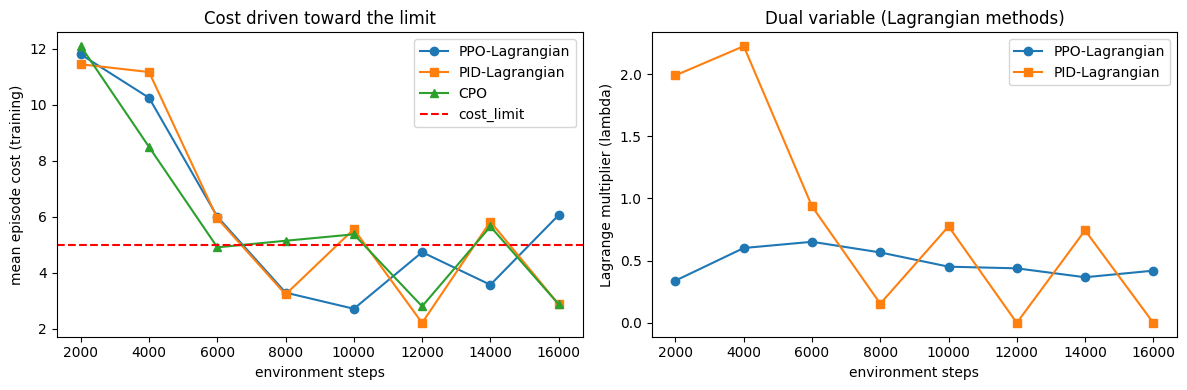

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(s_lag, c_lag, marker='o', label='PPO-Lagrangian')
ax1.plot(s_pid, c_pid, marker='s', label='PID-Lagrangian')
ax1.plot(s_cpo, c_cpo, marker='^', label='CPO')
ax1.axhline(COST_LIMIT, color='red', ls='--', label='cost_limit')
ax1.set_xlabel('environment steps'); ax1.set_ylabel('mean episode cost (training)')
ax1.set_title('Cost driven toward the limit'); ax1.legend()

ax2.plot(s_lag, l_lag, marker='o', label='PPO-Lagrangian')
ax2.plot(s_pid, l_pid, marker='s', label='PID-Lagrangian')
ax2.set_xlabel('environment steps'); ax2.set_ylabel('Lagrange multiplier (lambda)')
ax2.set_title('Dual variable (Lagrangian methods)'); ax2.legend()
plt.tight_layout(); plt.show()

In [7]:
unconstrained = PPOLagrangian(gym.make('CartPole-v1'), n_epochs=10,
                              **{**COMMON, 'cost_limit': 1e9})
unconstrained.learn(total_timesteps=TOTAL_STEPS)

rows = [('PPO-Lagrangian', ppolag), ('PID-Lagrangian', pidlag), ('CPO', cpo),
        ('Unconstrained PPO', unconstrained)]
print(f"{'algorithm':<20}{'costly-action freq':>20}{'mean episode cost':>20}")
for name, model in rows:
    freq, cost = evaluate(model)
    print(f'{name:<20}{freq:>20.2f}{cost:>20.1f}')

algorithm             costly-action freq   mean episode cost
PPO-Lagrangian                      0.00                 0.0
PID-Lagrangian                      0.00                 0.0
CPO                                 0.00                 0.0


Unconstrained PPO                   0.50               243.9


## Using a trained policy

Every baseline exposes `predict(obs, deterministic=True)` for the greedy action and a
`last_stats` dict with per-update diagnostics.

In [8]:
obs, _ = gym.make('CartPole-v1').reset(seed=0)
for name, model in [('PPO-Lagrangian', ppolag), ('PID-Lagrangian', pidlag), ('CPO', cpo)]:
    action, _ = model.predict(obs, deterministic=True)
    stats = {k: round(v, 3) for k, v in model.last_stats.items()}
    print(f'{name:<16} action={int(np.asarray(action))}  stats={stats}')

PPO-Lagrangian   action=1  stats={'policy_loss': 0.015, 'value_loss': 12.31, 'lagrangian_multiplier': 0.42, 'mean_cost_advantage': 0.72, 'mean_cost_return': 3.141, 'mean_episode_cost': 6.058}
PID-Lagrangian   action=1  stats={'policy_loss': -0.052, 'value_loss': 7.423, 'lagrangian_multiplier': 0.0, 'mean_cost_advantage': -1.003, 'mean_cost_return': 1.584, 'lambda_P': -0.532, 'lambda_I': 0.412, 'lambda_D': 0.005, 'mean_episode_cost': 2.873}
CPO              action=1  stats={'reward_policy_loss': -0.0, 'cost_policy_loss': -0.0, 'value_loss': 8.596, 'kl': 0.018, 'accepted': 1.0, 'optim_case': 3.0, 'lambda_star': 1.668, 'nu_star': 0.0, 'constraint_value_c': -2.126, 'mean_episode_cost': 2.874}
